<a href="https://colab.research.google.com/github/divya374r1/Neural-Network-and-Deep-Learning/blob/main/binary_and_multiclass_CNN(E4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

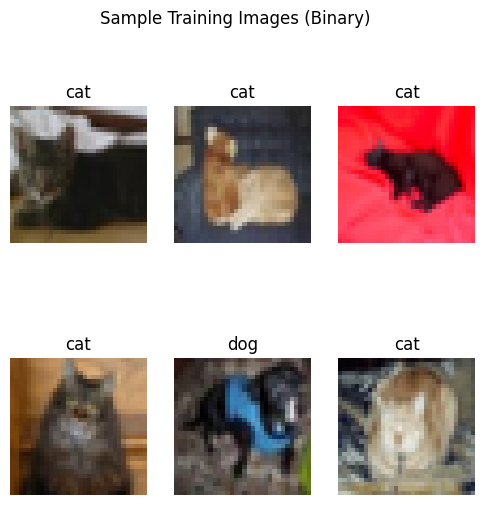

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.5882 - loss: 0.6664 - val_accuracy: 0.6910 - val_loss: 0.5779
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.6863 - loss: 0.5839 - val_accuracy: 0.6955 - val_loss: 0.5617
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.7180 - loss: 0.5450 - val_accuracy: 0.7305 - val_loss: 0.5329
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.7318 - loss: 0.5185 - val_accuracy: 0.7270 - val_loss: 0.5255
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.7708 - loss: 0.4740 - val_accuracy: 0.7470 - val_loss: 0.5168
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7414 - loss: 0.5251
Test Accuracy: 0.746999979019165


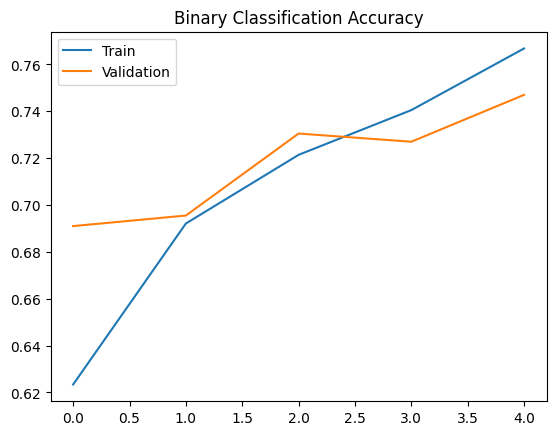

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/tmp/ipython-input-1235768047.py:82: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = selected_classes[int(prediction > 0.5)]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


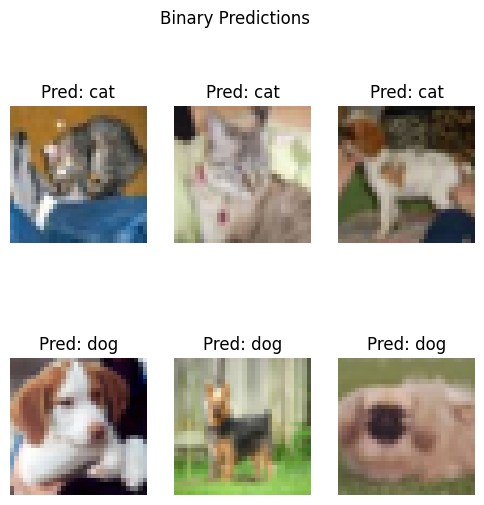

In [ ]:
# ======================================
# EXPERIMENT 4A - BINARY CNN WITH IMAGE OUTPUT
# Cat vs Dog using CIFAR-10
# ======================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_labels = ['airplane','automobile','bird','cat','deer',
                'dog','frog','horse','ship','truck']

# Select cat and dog
selected_classes = ['cat','dog']
selected_indices = [class_labels.index(c) for c in selected_classes]

train_filter = np.isin(y_train, selected_indices).flatten()
test_filter = np.isin(y_test, selected_indices).flatten()

x_train = x_train[train_filter]
y_train = y_train[train_filter]
x_test = x_test[test_filter]
y_test = y_test[test_filter]

# Relabel 0 and 1
label_map = {selected_indices[i]: i for i in range(2)}
y_train = np.array([label_map[y[0]] for y in y_train])
y_test = np.array([label_map[y[0]] for y in y_test])

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Show sample training images
plt.figure(figsize=(6,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_train[i])
    plt.title(selected_classes[y_train[i]])
    plt.axis("off")
plt.suptitle("Sample Training Images (Binary)")
plt.show()

# Build CNN
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,3,activation='relu',input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_test,y_test))

# Evaluate
loss, acc = model.evaluate(x_test,y_test)
print("Test Accuracy:", acc)

# Plot Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Binary Classification Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# Show Predictions
plt.figure(figsize=(6,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    prediction = model.predict(x_test[i].reshape(1,32,32,3))
    label = selected_classes[int(prediction > 0.5)]
    plt.imshow(x_test[i])
    plt.title("Pred: " + label)
    plt.axis("off")
plt.suptitle("Binary Predictions")
plt.show()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


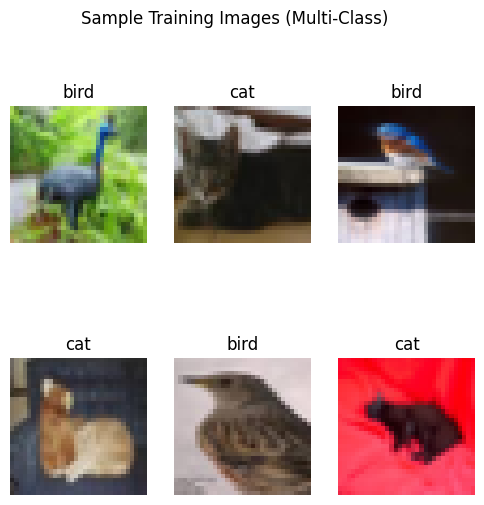

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.4896 - loss: 0.9924 - val_accuracy: 0.5830 - val_loss: 0.8940
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.6307 - loss: 0.8223 - val_accuracy: 0.6333 - val_loss: 0.8214
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.6732 - loss: 0.7370 - val_accuracy: 0.6657 - val_loss: 0.7480
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.7106 - loss: 0.6854 - val_accuracy: 0.6620 - val_loss: 0.7398
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.7345 - loss: 0.6266 - val_accuracy: 0.6730 - val_loss: 0.7631
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6776 - loss: 0.7547
Test Accuracy: 0.6729999780654907


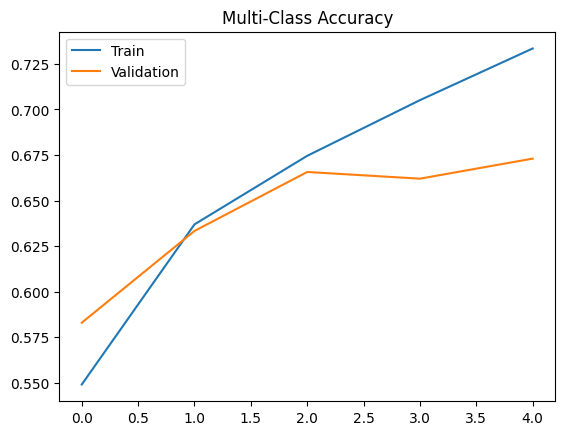

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


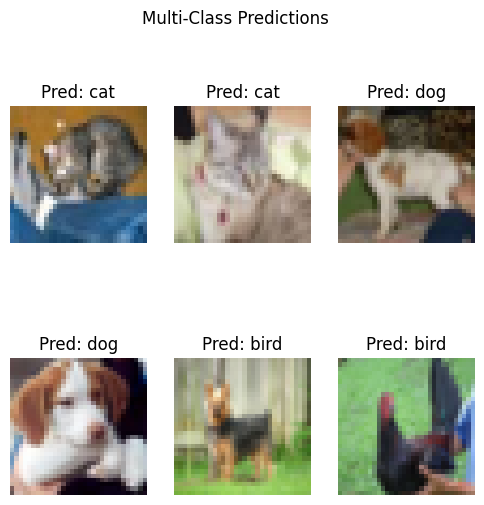

In [1]:

# ======================================
# EXPERIMENT 4B - MULTI-CLASS CNN WITH IMAGE OUTPUT
# Cat, Dog, Bird using CIFAR-10
# ======================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_labels = ['airplane','automobile','bird','cat','deer',
                'dog','frog','horse','ship','truck']

# Select cat, dog, bird
selected_classes = ['cat','dog','bird']
selected_indices = [class_labels.index(c) for c in selected_classes]

train_filter = np.isin(y_train, selected_indices).flatten()
test_filter = np.isin(y_test, selected_indices).flatten()

x_train = x_train[train_filter]
y_train = y_train[train_filter]
x_test = x_test[test_filter]
y_test = y_test[test_filter]

# Relabel to 0,1,2
label_map = {selected_indices[i]: i for i in range(3)}
y_train = np.array([label_map[y[0]] for y in y_train])
y_test = np.array([label_map[y[0]] for y in y_test])

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Show sample images
plt.figure(figsize=(6,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_train[i])
    plt.title(selected_classes[y_train[i]])
    plt.axis("off")
plt.suptitle("Sample Training Images (Multi-Class)")
plt.show()

# Build CNN
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,3,activation='relu',input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(3,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_test,y_test))

# Evaluate
loss, acc = model.evaluate(x_test,y_test)
print("Test Accuracy:", acc)

# Plot Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Multi-Class Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# Show Predictions
plt.figure(figsize=(6,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    prediction = model.predict(x_test[i].reshape(1,32,32,3))
    label = selected_classes[np.argmax(prediction)]
    plt.imshow(x_test[i])
    plt.title("Pred: " + label)
    plt.axis("off")
plt.suptitle("Multi-Class Predictions")
plt.show()
